In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  Firestore → JSON dump (async) — reads creds from $FIREBASE_CERT_PATH   ║
# ╚══════════════════════════════════════════════════════════════════════════╝
from __future__ import annotations

from constants import FIREBASE_CERT_PATH
import asyncio, json, os, datetime as dt
from pathlib import Path
from typing import Any, Dict, List

from tqdm.asyncio import tqdm                       # pip install tqdm
from google.cloud.firestore_v1 import GeoPoint
from google.cloud.firestore_v1.async_client import AsyncClient
from google.cloud.firestore_v1.async_collection import AsyncCollectionReference
from google.cloud.firestore_v1.async_document import AsyncDocumentReference
from google.oauth2 import service_account           # ⬅ for service-account creds


# ──────────────────────────────────────────────────────────────────────────────
# 0)  Global knobs                                                             │
# ──────────────────────────────────────────────────────────────────────────────
PAGE_SIZE         = 500      # docs per list_documents page  (≤ 500)
_MAX_CONCURRENCY  = 64       # simultaneous RPCs             (tune as needed)


# ──────────────────────────────────────────────────────────────────────────────
# 1)  Firestore value → JSON-serialisable (unchanged)                          │
# ──────────────────────────────────────────────────────────────────────────────
def _serialise_value(v: Any) -> Any:
    if v is None or isinstance(v, (bool, int, float, str)):
        return v
    if isinstance(v, list):
        return [_serialise_value(x) for x in v]
    if isinstance(v, dict):
        return {k: _serialise_value(x) for k, x in v.items()}
    if isinstance(v, dt.datetime):
        return v.isoformat()
    if isinstance(v, GeoPoint):
        return {"lat": v.latitude, "lon": v.longitude}
    if hasattr(v, "path"):                      # DocumentReference, etc.
        return v.path
    return str(v)


# ──────────────────────────────────────────────────────────────────────────────
# 2)  Pretty printer with inlined flat lists (unchanged)                       │
# ──────────────────────────────────────────────────────────────────────────────
def _is_prim(x: Any) -> bool:
    return x is None or isinstance(x, (bool, int, float, str))

def _pretty_inline(o: Any, *, indent: int = 2, _lvl: int = 0) -> str:
    pad, nxt = " " * (indent * _lvl), " " * (indent * (_lvl + 1))

    if isinstance(o, dict):
        if not o:
            return "{}"
        parts = [f'\n{nxt}{json.dumps(k)}: {_pretty_inline(v, indent=indent, _lvl=_lvl+1)}'
                 for k, v in o.items()]
        return "{" + ",".join(parts) + f"\n{pad}" + "}"

    if isinstance(o, list):
        if o and all(_is_prim(x) for x in o):
            return json.dumps(o, separators=(",", ": "))
        if not o:
            return "[]"
        parts = [f'\n{nxt}{_pretty_inline(v, indent=indent, _lvl=_lvl+1)}'
                 for v in o]
        return "[" + ",".join(parts) + f"\n{pad}]"

    return json.dumps(o, ensure_ascii=False)


# ──────────────────────────────────────────────────────────────────────────────
# 3)  Recursive *async* traversal  —  fixed progress bar                       │
# ──────────────────────────────────────────────────────────────────────────────
async def _dump_collection_async(
    col: AsyncCollectionReference,
    *,
    _depth: int,
    _sem: asyncio.Semaphore,
) -> List[Dict[str, Any]]:
    docs: List[Dict[str, Any]] = []

    # list refs once so we know the total
    refs = [d async for d in col.list_documents(page_size=PAGE_SIZE)]

    # progress bar only at top level
    bar = (
        tqdm(total=len(refs), desc=col.id, unit="doc", leave=True)
        if _depth == 0 else None
    )

    async def _fetch(ref: AsyncDocumentReference) -> Dict[str, Any]:
        async with _sem:
            snap = await ref.get()

        doc_json = {"_id": snap.id,
                    **{k: _serialise_value(v) for k, v in snap.to_dict().items()}}

        # recurse into sub-collections
        for sref in [s async for s in ref.collections()]:
            doc_json[sref.id] = await _dump_collection_async(
                sref, _depth=_depth + 1, _sem=_sem
            )
        return doc_json

    # schedule & collect
    tasks = [_fetch(r) for r in refs]
    for coro in asyncio.as_completed(tasks):
        docs.append(await coro)
        if bar:
            bar.update(1)

    if bar:
        bar.close()
    return docs


# ──────────────────────────────────────────────────────────────────────────────
# 4)  Public async entry-point                                                 │
# ──────────────────────────────────────────────────────────────────────────────
async def dump_firestore_async(
    root_path: str | None = None,
    *,
    output: str | Path | None = "spinel_orr.json",
    client: AsyncClient | None = None,
) -> Dict[str, Any] | List[Dict[str, Any]]:
    """
    Asynchronously serialise Firestore to JSON, using credentials specified
    by the env-var FIREBASE_CERT_PATH (service-account JSON).

    Example
    -------
    >>> data = await dump_firestore_async()                 # whole DB
    >>> await dump_firestore_async("materials")             # one collection
    """

    # ------------------------------------------------------------------ creds
    if client is None:
        cert_path = os.environ.get("FIREBASE_CERT_PATH")
        if not cert_path:
            raise RuntimeError("Set FIREBASE_CERT_PATH to your service-account JSON")
        creds = service_account.Credentials.from_service_account_file(cert_path)
        client = AsyncClient(project=creds.project_id, credentials=creds)

    sem = asyncio.Semaphore(_MAX_CONCURRENCY)

    # ---------------------------------------------------------------- traversal
    if root_path is None:
        serialisable: Dict[str, Any] = {
            c.id: await _dump_collection_async(c, _depth=0, _sem=sem)
            async for c in client.collections()
        }
    else:
        if len(root_path.split("/")) % 2 == 0:
            raise ValueError("root_path must be a *collection* path, not document")
        root = client.collection(root_path)
        serialisable = {root.id: await _dump_collection_async(root, _depth=0, _sem=sem)}

    # ------------------------------------------------------------------ output
    if output:
        Path(output).write_text(_pretty_inline(serialisable) + "\n", encoding="utf-8")
        print(f"Wrote {output}")

    # graceful shutdown (works for both sync & async .close())
    if hasattr(client, "close"):
        maybe_coro = client.close()
        if asyncio.iscoroutine(maybe_coro):
            await maybe_coro

    return serialisable


In [ ]:
os.environ["FIREBASE_CERT_PATH"] = FIREBASE_CERT_PATH
json_db = await dump_firestore_async()

studies: 100%|██████████| 887/887 [00:07<00:00, 121.18doc/s]


Wrote firestore_dump.json


TypeError: object NoneType can't be used in 'await' expression

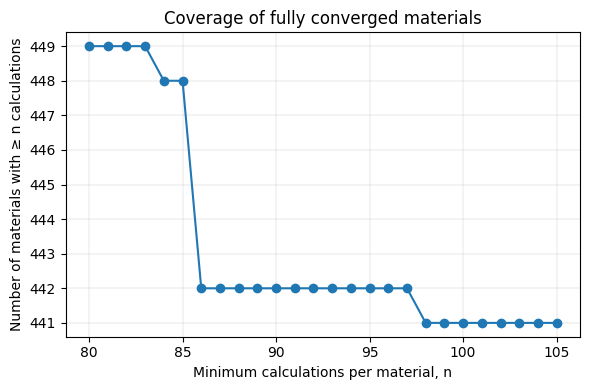

In [ ]:
import json
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

# --- 1.  load dump ----------------------------------------------------------
dump_path = Path("spinel_orr.json")      # <- adjust if needed
materials = json.loads(dump_path.read_text())["materials"]

# --- 2.  count calculations per material -----------------------------------
counts = Counter()
for mat in materials:
    mat_id = mat["_id"]
    for facet, ads_list in mat.items():
        if facet in ("_id", "timestamp"):
            continue
        for ads in ads_list:
            counts[mat_id] += len(ads["calcs"])

# --- 3.  cumulative distribution N(≥ n) ------------------------------------
max_n = 105 #max(counts.values())
xs = range(80, max_n + 1)
ys = [sum(1 for c in counts.values() if c >= n) for n in xs]

# --- 4.  plot ---------------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.plot(xs, ys, marker="o")
plt.xlabel("Minimum calculations per material, n")
plt.ylabel("Number of materials with ≥ n calculations")
plt.title("Coverage of fully converged materials")
plt.grid(True, which="both", linewidth=0.2)
plt.tight_layout()
plt.show()


In [ ]:
import json
from pathlib import Path
from collections import Counter

# ── 1.  Load the Firestore dump ────────────────────────────────────────────────
dump_path = Path("spinel_orr.json")   # adjust if needed
data = json.loads(dump_path.read_text())["materials"]

# ── 2.  Bucket counts by facet ────────────────────────────────────────────────
materials_per_facet   = Counter()   # e.g. bulk → 411
calcs_per_facet       = Counter()   # e.g. 100o_5x3 → 3.2×10⁴

for mat in data:
    for facet_name, adsorbates in mat.items():
        if facet_name in ("_id", "timestamp"):          # skip meta fields
            continue
        materials_per_facet[facet_name] += 1
        for ads in adsorbates:
            calcs_per_facet[facet_name] += len(ads["calcs"])

# ── 3.  Display nicely ────────────────────────────────────────────────────────
print("── Materials per facet ──")
for facet, n in materials_per_facet.most_common():
    print(f"{facet:20s} : {n:5d}")

print("\n── Calculations per facet ──")
for facet, n in calcs_per_facet.most_common():
    print(f"{facet:20s} : {n:7d}")


── Materials per facet ──
bulk                 :   963
100o_5x3             :   492
100s_5x3             :   183
111s_8x5             :    40
111b_9x4             :     9
molecule             :     3
100s_6x2             :     2
111s_3x2             :     1
100s_hl7_slab        :     1

── Calculations per facet ──
100o_5x3             :   62883
100s_5x3             :   13798
111s_8x5             :    3940
bulk                 :    1388
100s_6x2             :     588
111b_9x4             :     555
100s_hl7_slab        :      61
111s_3x2             :       7
molecule             :       4


In [2]:
# %%time
JSON_PATH   = "spinel_orr.json"     # ← change if needed
SQLITE_PATH = "spinel_orr.sqlite"

import json, sqlite3, pathlib, math, itertools

# ---------------------------------------------------------------------------
# 1) Load JSON once (≈300 MB) ------------------------------------------------
# ---------------------------------------------------------------------------
data = json.loads(pathlib.Path(JSON_PATH).read_text())
materials_json = data["materials"]
studies_json   = data["studies"]

# ---------------------------------------------------------------------------
# 2) Discover ALL calc-level keys and infer SQLite types --------------------
# ---------------------------------------------------------------------------
field_types = {}            # original_key ➜ "INTEGER" | "REAL" | "TEXT"

def promote(stored, new):
    order = ["INTEGER", "REAL", "TEXT"]
    return order[max(order.index(stored), order.index(new))]

def update_type(key, value):
    if value is None:
        return
    if isinstance(value, bool):
        t = "INTEGER"
    elif isinstance(value, int):
        t = "INTEGER"
    elif isinstance(value, float):
        t = "REAL"
    elif isinstance(value, (list, dict)):
        t = "TEXT"
    else:
        t = "TEXT"
    field_types[key] = promote(field_types.get(key, t), t)

for mat in materials_json:
    for facet, ads_list in mat.items():
        if facet in ("_id", "timestamp"):
            continue
        for ads in ads_list:
            for calc in ads["calcs"]:
                for k, v in calc.items():
                    if k == "_id":
                        continue
                    update_type(k, v)

print(f"Discovered {len(field_types)} calc fields")

# ---------------------------------------------------------------------------
# 3) Resolve name clashes with hierarchy columns ----------------------------
# ---------------------------------------------------------------------------
reserved  = {c.lower() for c in ("material_id", "facet", "adsorbate_id", "calc_id")}
renamed   = {}                 # original_key ➜ new_column_name

for k in list(field_types):
    if k.lower() in reserved:
        new_k = f"calc_{k}"
        field_types[new_k] = field_types.pop(k)
        renamed[k] = new_k

# original-key order (sorted for repeatability)
orig_keys = sorted({*field_types.keys()} - set(renamed.values()))     # keys not renamed
orig_keys += sorted(renamed.keys())                                   # add the ones we renamed
calc_column_names = [renamed.get(k, k) for k in orig_keys]

# ---------------------------------------------------------------------------
# 4) Create SQLite DB --------------------------------------------------------
# ---------------------------------------------------------------------------
pathlib.Path(SQLITE_PATH).unlink(missing_ok=True)     # start fresh
con = sqlite3.connect(SQLITE_PATH)
cur = con.cursor()
cur.executescript("""
PRAGMA journal_mode=OFF;
PRAGMA synchronous=OFF;
PRAGMA temp_store=MEMORY;

CREATE TABLE materials(
    material_id TEXT PRIMARY KEY,
    timestamp   TEXT
);
""")

# dynamic calcs table
fixed_cols = {
    "material_id": "TEXT",
    "facet": "TEXT",
    "adsorbate_id": "TEXT",
    "calc_id": "TEXT"
}
ddl_cols = [f"{c} {tp}"             for c, tp in fixed_cols.items()]
ddl_cols += [f"{c} {field_types[c]}" for c in calc_column_names]
ddl_cols.append("UNIQUE(material_id, facet, adsorbate_id, calc_id)")
cur.execute(f"CREATE TABLE calcs ({', '.join(ddl_cols)})")

# studies table (as before)
cur.executescript("""
CREATE TABLE studies(
    study_id   TEXT PRIMARY KEY,
    Material   TEXT,
    Facet      TEXT,
    Layers     INTEGER,
    Frozen_layers INTEGER,
    Base_dft_ref TEXT,
    free_species_name           TEXT,
    free_species_phase          TEXT,
    free_species_dft_ref        TEXT,
    free_species_mm             TEXT,
    step_index                  TEXT,
    step_dft_ref                TEXT,
    step_free_species_counts    TEXT,
    timestamp  TEXT
);
""")

# ---------------------------------------------------------------------------
# 5) Insert rows in batches --------------------------------------------------
# ---------------------------------------------------------------------------
cur.executemany("INSERT OR IGNORE INTO materials VALUES (?,?)",
                [(m["_id"], m.get("timestamp")) for m in materials_json])

insert_cols   = list(fixed_cols.keys()) + calc_column_names
placeholders  = ", ".join("?" * len(insert_cols))
insert_sql    = f"INSERT OR IGNORE INTO calcs ({', '.join(insert_cols)}) VALUES ({placeholders})"

batch, BATCH = [], 10_000
def flush():
    if batch:
        cur.executemany(insert_sql, batch)
        batch.clear()

for mat in materials_json:
    mat_id = mat["_id"]
    for facet, ads_list in mat.items():
        if facet in ("_id", "timestamp"):
            continue
        for ads in ads_list:
            ads_id = ads["_id"]
            for calc in ads["calcs"]:
                row_fixed = [mat_id, facet, ads_id, calc["_id"]]
                row_calc  = []
                for orig in orig_keys:
                    v = calc.get(orig)
                    if isinstance(v, (list, dict)):
                        v = json.dumps(v, separators=(",", ":"))
                    elif isinstance(v, bool):
                        v = int(v)
                    row_calc.append(v)
                batch.append(row_fixed + row_calc)
                if len(batch) >= BATCH:
                    flush()
flush()
con.commit()

# studies
stud_rows = [(
    st["_id"], st["Material"], st["Facet"], st["Layers"],
    st.get("Frozen_layers"), st["Base_dft_ref"],
    *(json.dumps(st[k]) for k in
      ("free_species_name","free_species_phase","free_species_dft_ref",
       "free_species_molar_mass_gpMol","step_index","step_dft_ref",
       "step_free_species_counts")),
    st.get("timestamp")
) for st in studies_json]
cur.executemany("INSERT OR IGNORE INTO studies VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?)", stud_rows)
con.commit()

# ---------------------------------------------------------------------------
# 6) Report ------------------------------------------------------------------
# ---------------------------------------------------------------------------
n_m, n_c, n_s = (cur.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
                 for t in ("materials", "calcs", "studies"))
size_MB = pathlib.Path(SQLITE_PATH).stat().st_size / 1_048_576
print(f"✓ Loaded {n_m} materials, {n_c:,} calcs, {n_s} studies")
print(f"SQLite size: {size_MB:.1f} MB")

con.close()


Discovered 47 calc fields
✓ Loaded 966 materials, 83,224 calcs, 887 studies
SQLite size: 1026.1 MB


In [3]:
# %%time
import sqlite3, json, textwrap, random, pprint

DB = "spinel_orr.sqlite"          # adjust if you changed the name
con = sqlite3.connect(DB)
cur = con.cursor()

# ------------------------------------------------------------------
# 1)  arbitrary CALC entry
# ------------------------------------------------------------------
calc_cols = [c[1] for c in cur.execute("PRAGMA table_info(calcs)")]
calc_row  = cur.execute(
    "SELECT * FROM calcs ORDER BY RANDOM() LIMIT 1"
).fetchone()
calc_dict = dict(zip(calc_cols, calc_row))

print("="*90)
print(f"RANDOM calc entry  ⟶  material {calc_dict['material_id']}")
print("="*90)
for k, v in calc_dict.items():
    if v is None:
        continue
    # pretty-print JSON strings for arrays/dicts
    if isinstance(v, str) and (v.startswith('[') or v.startswith('{')):
        print(f"{k} :")
        print(textwrap.indent(json.dumps(json.loads(v), indent=2)[:500] + ' …', '  '))
    else:
        print(f"{k:<25}: {v}")
print("\n\n")

# ------------------------------------------------------------------
# 2)  arbitrary STUDY entry
# ------------------------------------------------------------------
study_cols = [c[1] for c in cur.execute("PRAGMA table_info(studies)")]
study_row  = cur.execute(
    "SELECT * FROM studies ORDER BY RANDOM() LIMIT 1"
).fetchone()
study_dict = dict(zip(study_cols, study_row))

print("="*90)
print(f"RANDOM study entry  ⟶  {study_dict['study_id']}")
print("="*90)
for k, v in study_dict.items():
    if v is None:
        continue
    if k.startswith("free_species") or k.startswith("step_"):
        print(f"{k} :")
        print(textwrap.indent(json.dumps(json.loads(v), indent=2)[:500] + ' …', '  '))
    else:
        print(f"{k:<25}: {v}")

con.close()


RANDOM calc entry  ⟶  material Co3O4
material_id              : Co3O4
facet                    : 100o_5x3
adsorbate_id             : O1-xH_O2-xH_O4-xH
calc_id                  : 331_candle_fs025
Adsorbate                : O1-xH_O2-xH_O4-xH
Dft_utc_timestamp_s      : 1742709891
Elec_smearing_eV         : 0.025
Etot_eV                  : -130795.2090126851
Fluid                    : candle
Forces_max_L2_eVpA       : 0.011747934052590437
Forces_sum_L2_eVpA       : 0.10276325032922064
Frozen_layers            : 3
GPUs                     : 2
Geo                      : slab
Kpoints                  : 331
Last_modified_utc_ts     : 2025-03-23T12:19:43+00:00
Lattice_abc :
  [
    8.158854239199627,
    8.158854239199627,
    23.38852145406156
  ] …
Lattice_abc_start :
  [
    8.158854239199627,
    8.158854239199627,
    23.38852145406156
  ] …
Lattice_type             : Orthorhombic
Lattice_type_start       : Orthorhombic
Layers                   : 5
Material                 : Co3O4
Processe

In [6]:
# %%time
"""
Auto-generate a Markdown schema snippet with proper column names
"""
import sqlite3, textwrap

DB = "spinel_orr.sqlite"        # adjust if needed
TABLES = ("materials", "calcs", "studies")

md = ["## Database schema (auto-generated)\n"]

with sqlite3.connect(DB) as con:
    for tbl in TABLES:
        info = con.execute(f"PRAGMA table_info({tbl})").fetchall()
        # info columns: cid, name, type, notnull, dflt_value, pk
        md.append(f"### `{tbl}`\n")
        md.append("| column | type | description |\n"
                  "|--------|------|--------------|\n")
        for cid, name, ctype, notnull, dflt, pk in info:
            md.append(f"| `{name}` | {ctype} |  |\n")
        md.append("\n")

schema_md = "".join(md)
print(schema_md)


## Database schema (auto-generated)
### `materials`
| column | type | description |
|--------|------|--------------|
| `material_id` | TEXT |  |
| `timestamp` | TEXT |  |

### `calcs`
| column | type | description |
|--------|------|--------------|
| `material_id` | TEXT |  |
| `facet` | TEXT |  |
| `adsorbate_id` | TEXT |  |
| `calc_id` | TEXT |  |
| `Adsorbate` | TEXT |  |
| `Bond_length_A` | REAL |  |
| `Dft_utc_timestamp_s` | INTEGER |  |
| `Elec_smearing_eV` | REAL |  |
| `Etot_eV` | REAL |  |
| `Fluid` | TEXT |  |
| `Forces_max_L2_eVpA` | REAL |  |
| `Forces_sum_L2_eVpA` | REAL |  |
| `Frozen_layers` | INTEGER |  |
| `GPUs` | INTEGER |  |
| `Geo` | TEXT |  |
| `Kpoints` | TEXT |  |
| `Last_modified_utc_ts` | TEXT |  |
| `Lattice_abc` | TEXT |  |
| `Lattice_abc_start` | TEXT |  |
| `Lattice_type` | TEXT |  |
| `Lattice_type_start` | TEXT |  |
| `Layers` | INTEGER |  |
| `Lock_depth` | INTEGER |  |
| `Material` | TEXT |  |
| `Processes` | INTEGER |  |
| `Python_error` | TEXT |  |
|